In [1]:
from sklearn.datasets import make_classification
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from scipy.spatial import Voronoi, voronoi_plot_2d


from __future__ import division
import numpy as np
from numpy.random import rand
import matplotlib.pyplot as plt
import matplotlib as mpl
from numba import jit
import os
import re
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sys import exit

In [2]:
plt.rcParams.update({'font.size': 12,
                     'lines.linewidth': 3,
                     'lines.markersize': 3,
                     "font.family": "serif",
                     'font.weight': 'normal',
                     "mathtext.fontset" : "stix",
                     "figure.dpi":200,
                     "legend.title_fontsize":12,
                     "legend.fontsize":9
                     })

In [3]:
def sort_beta(file):
    #print(file)
    beta = re.search('beta_(.+?)_', file).group(1)
    return float(beta)

In [4]:
@jit(nopython=True)
def StaggeredMagnetization(data, N):
    #print(data)
    
    #You have to unravel the array in a snake path (-_-)
    data = np.where(np.arange(len(data))[:,None]%2,data[:,::-1],data).ravel()
    
    #print(data)
    
    staggered_magnetization =np.zeros(N**2)
    for i in range(N**2):
        staggered_magnetization[i]=((-1)**(i))*data[i]
        
    result = np.sum(staggered_magnetization)/(N**2)
    return(result)

@jit(nopython=True)
def AntiferroOrderParam_SquareLattice(data, N):
    total_order = 0
    #print(N)
    #print(data)
    for a in range(N):
        for b in range(N):
            nb = np.zeros(4)
            spin = data[a,b]
            #print(spin)
            nb[0] = data[(a+1)%N,b] 
            nb[1] = data[a,(b+1)%N] 
            nb[2] = data[(a-1)%N,b] 
            nb[3] = data[a,(b-1)%N]
            
            order = 0
            for i in range(4):
                if spin * nb[i]== -1:
                    order+=1
                else: order+=0
            order/=4
            #print(nb)
            total_order += order
    return(total_order/(N**2))
            


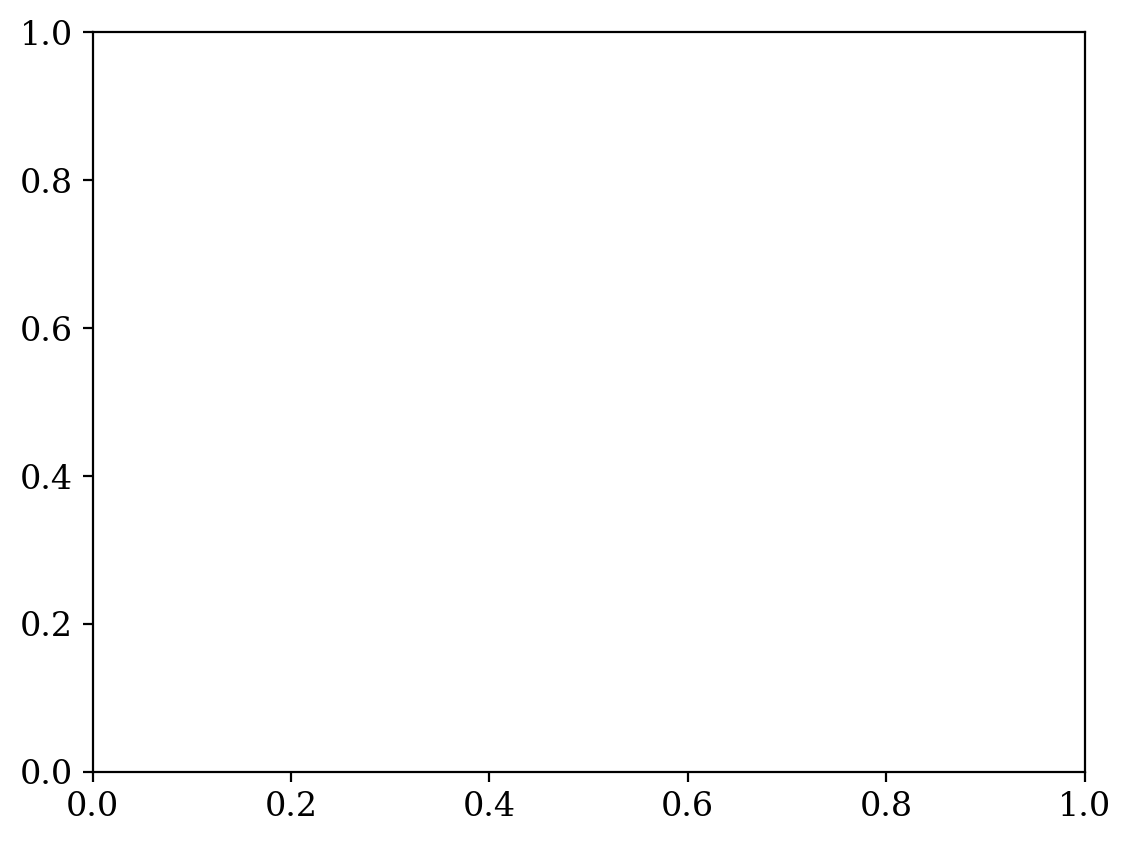

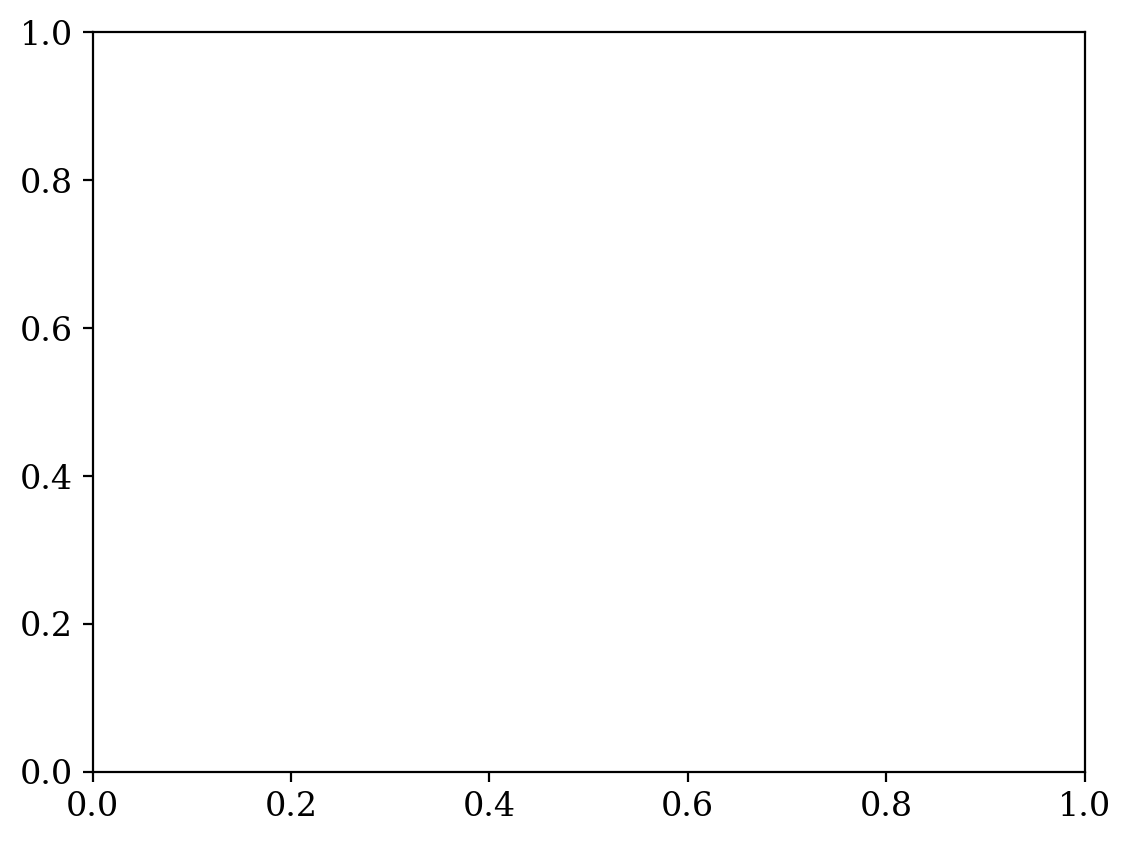

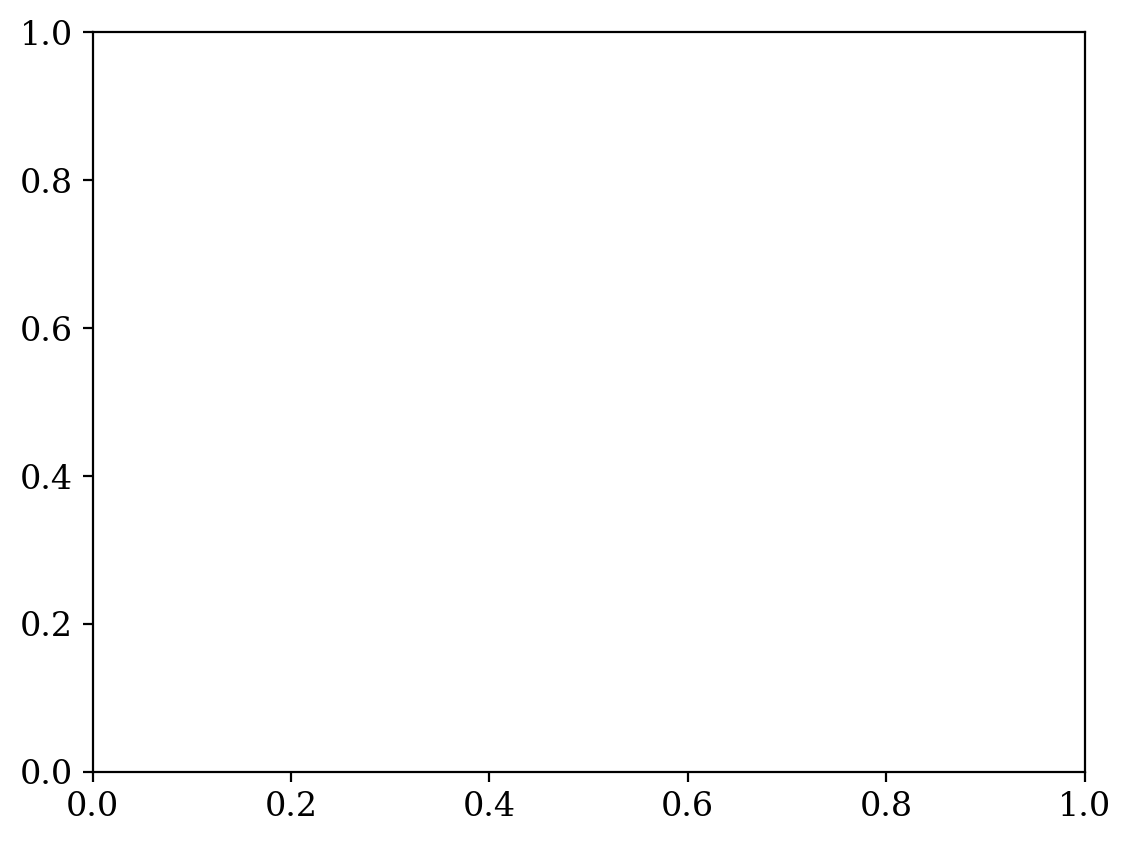

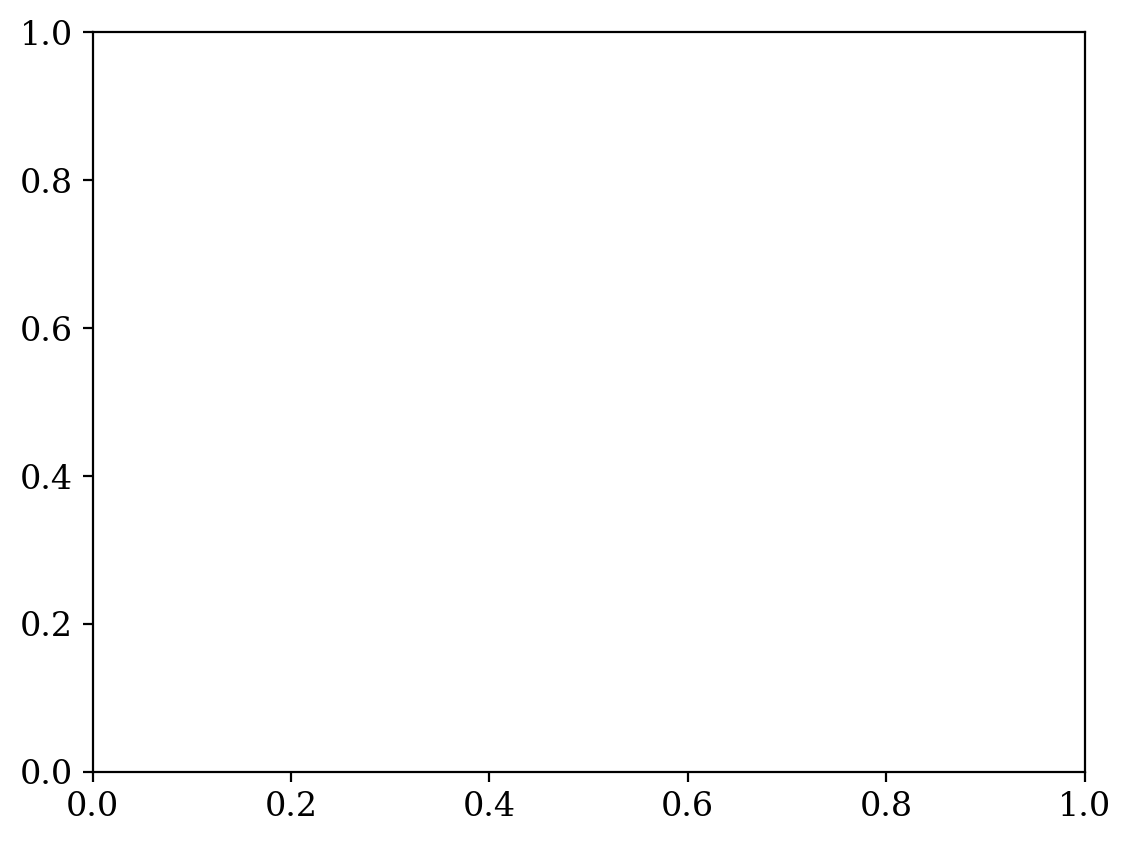

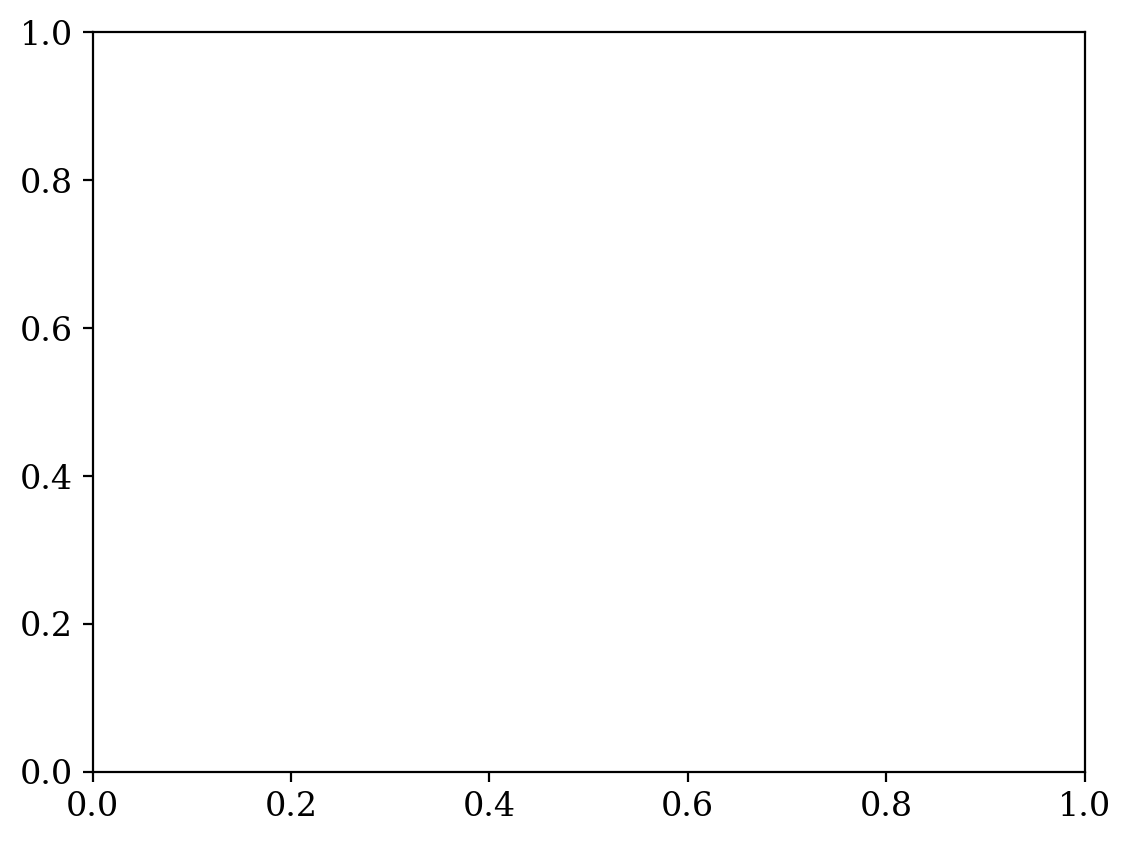

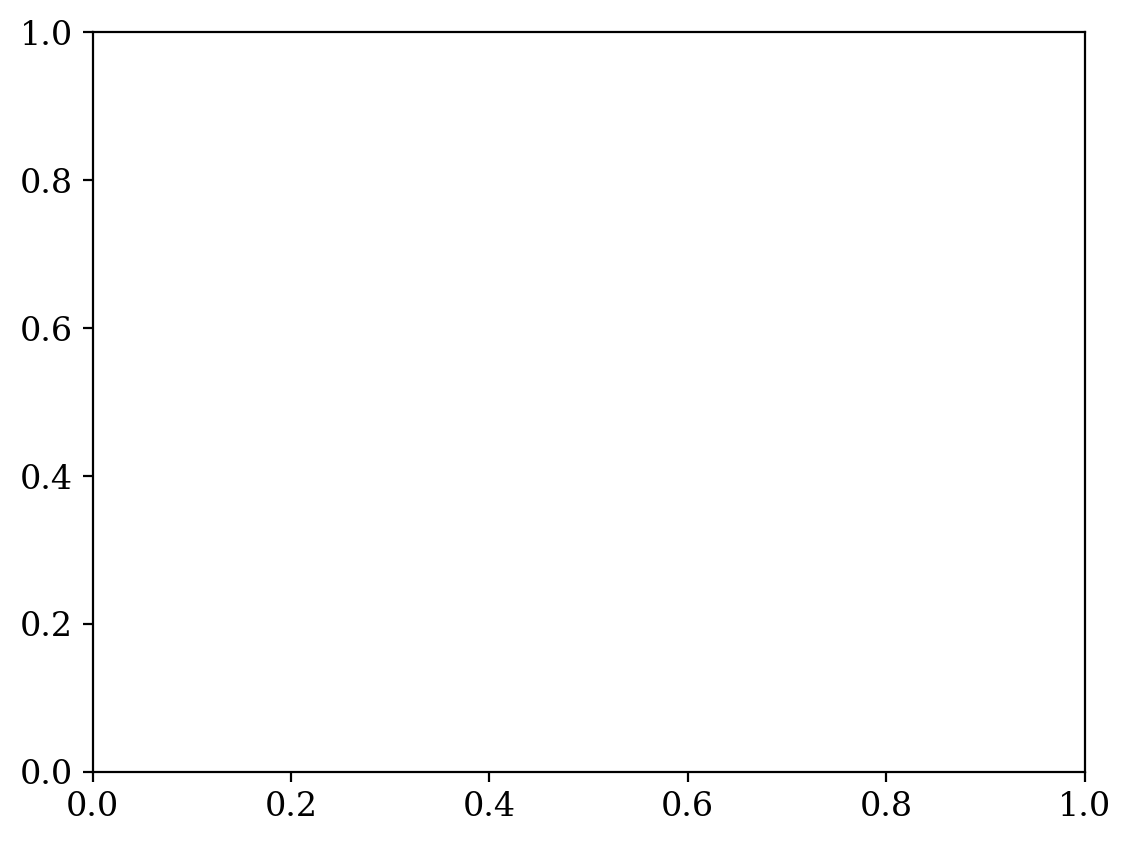

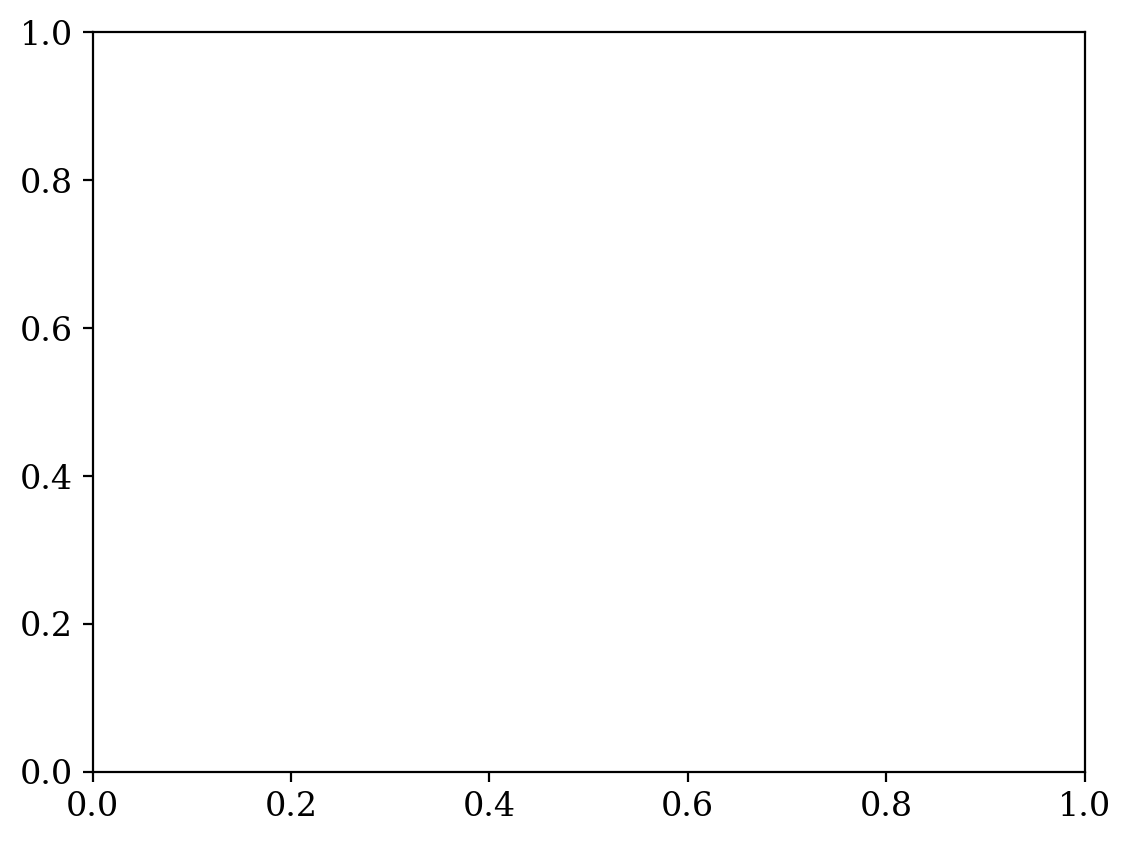

In [5]:
fig_varPCA, ax_varPCA = plt.subplots();

fig_tSNE_1, ax_tSNE_1 = plt.subplots();
fig_PCA_1, ax_PCA_1 = plt.subplots();

fig_tSNE_2, ax_tSNE_2 = plt.subplots();
fig_PCA_2, ax_PCA_2 = plt.subplots();

fig_tSNE_3, ax_tSNE_3 = plt.subplots();
fig_PCA_3, ax_PCA_3 = plt.subplots();



In [6]:
N = 30
type_folder = 'ferro'

(2000, 30, 30)
3.5


/var/folders/c3/v12nq2x14cq73wqt20_541t80000gp/T/ipykernel_85638/3149279271.py:35: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  X= torch.tensor(X, dtype=torch.float)
/var/folders/c3/v12nq2x14cq73wqt20_541t80000gp/T/ipykernel_85638/3149279271.py:47: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y= torch.tensor(y, dtype=torch.long)


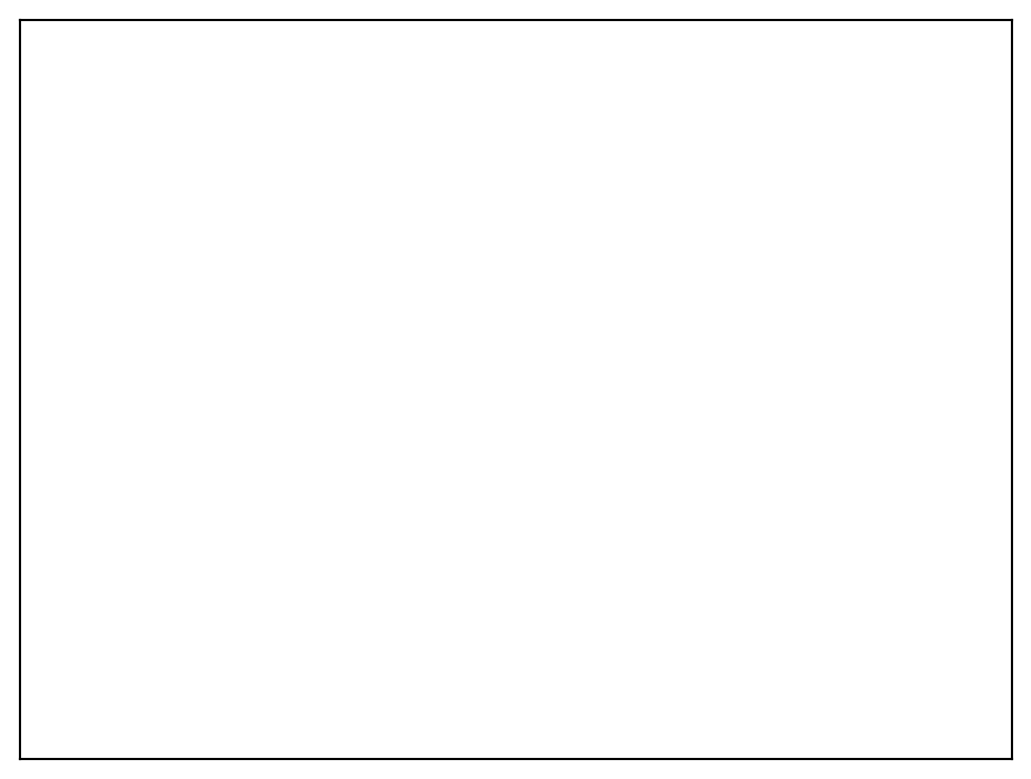

In [7]:
numCopies = 1

inputfolder ='./'+type_folder+'/data_N_'+str(N)+'_test'
myfiles = os.listdir(inputfolder)
#myfiles.remove('.DS_Store')
myfiles.sort(key = sort_beta)

betas= []
labels = []
data = np.zeros((  int(len(myfiles)) ,N,N))
for i in range(len(myfiles)):
    #print(myfiles[i])

    beta = re.search('beta_(.+?)_', myfiles[i]).group(1)
    betas.append(float(beta))
    data[i,:] = np.loadtxt(inputfolder+'/'+str(myfiles[i]))
    if 1/float(beta) > 2.269:
        labels.append(0) #paramagnet above Tc
    else: labels.append(1) #ferromagnet below Tc

data = np.repeat(data, numCopies, axis=0)
print(data.shape)
#     N=2
#     data=data[:,:N, :N]
#     print(data.shape)

#     #flip half of the spins at each temperature to double configurations in data
#     for i in range(int(len(data)/int(numCopies/2))):
#         if (i % 2) == 0:
#             #print(i*int(numCopies/2),(i+1)*int(numCopies/2))
#             data[i*int(numCopies/2):(i+1)*int(numCopies/2)]*=-1


X = torch.from_numpy(data)
X= torch.tensor(X, dtype=torch.float)

X = X.reshape(X.shape[0], -1)

#print(tsne.kl_divergence_)
#print(X_tsne)

y = np.asarray(labels)
y=np.repeat(y,numCopies)

#print(y.shape)
y = torch.from_numpy(y)
y= torch.tensor(y, dtype=torch.long)


betas=np.asarray(betas)
betas = np.repeat(betas, numCopies)
Temps = 1/betas

Xfig, Yfig = np.meshgrid(range(N), range(N))
plt.figure() 
#plt.setp(sp.get_yticklabels(), visible=False)
#plt.setp(sp.get_xticklabels(), visible=False)      
plt.pcolormesh(Xfig, Yfig, data[-1], cmap=plt.cm.binary);
# getting current axes
a = plt.gca()

# set visibility of x-axis as False
xax = a.axes.get_xaxis()
xax = xax.set_visible(False)

# set visibility of y-axis as False
yax = a.axes.get_yaxis()
yax = yax.set_visible(False)
plt.axis('tight') 
print(1/betas[0])

#First color map

c_norm = mpl.colors.Normalize(vmin=np.min(Temps), vmax=np.max(Temps))

c_map  = mpl.cm.RdYlBu_r

s_map  = mpl.cm.ScalarMappable(cmap=c_map, norm=c_norm)
s_map.set_array([])

#Second color map

c_norm2 = mpl.colors.Normalize(vmin=-1, vmax=1)

c_map2  = mpl.cm.RdYlBu_r

s_map2  = mpl.cm.ScalarMappable(cmap=c_map2, norm=c_norm2)
s_map2.set_array([])

#Third color map

c_norm3 = mpl.colors.Normalize(vmin=0, vmax=1)

c_map3  = mpl.cm.RdYlBu_r

s_map3  = mpl.cm.ScalarMappable(cmap=c_map3, norm=c_norm3)
s_map3.set_array([])



In [8]:
#Dimensionality Reduction
pca = PCA(n_components = 0.99)
X_pca = pca.fit_transform(X)
print(X_pca.shape)
variance_PCA = pca.explained_variance_ratio_

tsne = TSNE(n_components=2)
X_tsne = tsne.fit_transform(X)

kmeans_PCA = KMeans(init='k-means++', n_clusters=3, n_init='auto')
kmeans_PCA.fit(X_pca)

centroids_PCA = kmeans_PCA.cluster_centers_

# kmeans_tSNE = KMeans(init='k-means++', n_clusters=3, n_init='auto')
# kmeans_tSNE.fit(X_tsne)

# centroids_tSNE = kmeans_tSNE.cluster_centers_


(2000, 689)


In [9]:
#Compute order parameter and plot PCA
order_param = np.zeros(len(X_pca))
staggered_magnetization = np.zeros(len(X_pca))
magnetization = np.zeros(len(X_pca))
colors_Temp = []
colors_Magnetization = []
colors_Stagg_Magnetization = []

for p in range(len(X_pca)):
    #if Temps[p]<2.269: continue

    magnetization[p] = np.sum(data[p])/(N**2)
    staggered_magnetization[p] = StaggeredMagnetization( data[p], N)
    colors_Temp.append(s_map.to_rgba(float(Temps[p])))
    colors_Magnetization.append(s_map2.to_rgba(float(magnetization[p])))
    colors_Stagg_Magnetization.append(s_map2.to_rgba(float(staggered_magnetization[p])))

colors_Temp = np.asarray(colors_Temp)
colors_Magnetization = np.asarray(colors_Magnetization)
colors_Stagg_Magnetization = np.asarray(colors_Stagg_Magnetization)

In [10]:



ax_tSNE_1.scatter(X_tsne[:, 0], X_tsne[:, 1], color = colors_Temp,  s=3, edgecolors='black', linewidth=0.25)
ax_PCA_1.scatter(X_pca[:, 0], X_pca[:, 1], color = colors_Temp,  s=3, edgecolors='black', linewidth=0.25)


ax_tSNE_2.scatter(X_tsne[:, 0], X_tsne[:, 1], color = colors_Magnetization,  s=3, edgecolors='black', linewidth=0.25)
ax_PCA_2.scatter(X_pca[:, 0], X_pca[:, 1], color = colors_Magnetization,  s=3, edgecolors='black', linewidth=0.25)

ax_tSNE_3.scatter(X_tsne[:, 0], X_tsne[:, 1], color = colors_Stagg_Magnetization, s=3, edgecolors='black', linewidth=0.25)
ax_PCA_3.scatter(X_pca[:, 0], X_pca[:, 1], color = colors_Stagg_Magnetization, s=3, edgecolors='black', linewidth=0.25)



ax_PCA_1.scatter(centroids_PCA[:, 0], centroids_PCA[:, 1],
        marker='x', s=169, linewidths=3,
        color='palegreen', edgecolors='black', zorder=10)
ax_PCA_2.scatter(centroids_PCA[:, 0], centroids_PCA[:, 1],
        marker='x', s=169, linewidths=3,
        color='palegreen', edgecolors='black', zorder=10)
ax_PCA_3.scatter(centroids_PCA[:, 0], centroids_PCA[:, 1],
        marker='x', s=169, linewidths=3,
        color='palegreen', edgecolors='black', zorder=10)

# ax_tSNE_1.scatter(centroids_tSNE[:, 0], centroids_tSNE[:, 1],
#         marker='x', s=169, linewidths=3,
#         color='black', zorder=10)
# ax_tSNE_2.scatter(centroids_tSNE[:, 0], centroids_tSNE[:, 1],
#         marker='x', s=169, linewidths=3,
#         color='black', zorder=10)
# ax_tSNE_3.scatter(centroids_tSNE[:, 0], centroids_tSNE[:, 1],
#         marker='x', s=169, linewidths=3,
#         color='black', zorder=10)


ax_PCA_1.set_xticks([])
ax_PCA_1.set_yticks([])

ax_PCA_1.set_xlabel(r'$c_1$',  fontsize=24)
ax_PCA_1.set_ylabel(r'$c_2$',  fontsize=24)

ax_PCA_2.set_xticks([])
ax_PCA_2.set_yticks([])

ax_PCA_2.set_xlabel(r'$c_1$',  fontsize=24)
ax_PCA_2.set_ylabel(r'$c_2$',  fontsize=24)

ax_PCA_3.set_xticks([])
ax_PCA_3.set_yticks([])

ax_PCA_3.set_xlabel(r'$c_1$',  fontsize=24)
ax_PCA_3.set_ylabel(r'$c_2$',  fontsize=24)





ax_varPCA.plot(np.arange(1, 11), variance_PCA[:10], marker='.')
ax_varPCA.set_title('Explained variance')
ax_varPCA.set_xlabel(r"$c$",  fontsize=24)
ax_varPCA.set_ylabel(r"$ \tilde{\lambda}_c $" ,  fontsize=24)
ax_varPCA.set_yscale('log')


ax_tSNE_1.set_title('t-SNE '+str(N)+'x'+str(N)+' '+ type_folder)
ax_PCA_1.set_title('PCA '+str(N)+'x'+str(N)+' '+ type_folder)

ax_tSNE_2.set_title('t-SNE '+str(N)+'x'+str(N)+' '+ type_folder)
ax_PCA_2.set_title('PCA '+str(N)+'x'+str(N)+' '+ type_folder)

ax_tSNE_3.set_title('t-SNE '+str(N)+'x'+str(N)+' '+ type_folder)
ax_PCA_3.set_title('PCA '+str(N)+'x'+str(N)+' '+ type_folder)
    #print(betas.shape)

cb_tSNE_1 = fig_tSNE_1.colorbar(s_map )
cb_tSNE_2 = fig_tSNE_2.colorbar(s_map2)
cb_tSNE_3 = fig_tSNE_3.colorbar(s_map2)


cb_PCA_1 = fig_PCA_1.colorbar(s_map)
cb_PCA_2 = fig_PCA_2.colorbar(s_map2)
cb_PCA_3 = fig_PCA_3.colorbar(s_map2)


cb_tSNE_1.ax.set_title(r'$\mathrm{T}$')
cb_tSNE_2.ax.set_title(r'$\mathrm{ M}$')
cb_tSNE_3.ax.set_title(r'$\mathrm{M_s }$')

cb_PCA_1.ax.set_title(r'$\mathrm{T}$', fontsize=24)
cb_PCA_2.ax.set_title(r'$\mathrm{ M}$', fontsize=24)
cb_PCA_3.ax.set_title(r'$\mathrm{M_s }$', fontsize=24)



/var/folders/c3/v12nq2x14cq73wqt20_541t80000gp/T/ipykernel_85638/1815584506.py:13: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax_PCA_1.scatter(centroids_PCA[:, 0], centroids_PCA[:, 1],
/var/folders/c3/v12nq2x14cq73wqt20_541t80000gp/T/ipykernel_85638/1815584506.py:16: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax_PCA_2.scatter(centroids_PCA[:, 0], centroids_PCA[:, 1],
/var/folders/c3/v12nq2x14cq73wqt20_541t80000gp/T/ipykernel_85638/1815584506.py:19: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax_PCA_3.scatter(centroids_PCA[:, 0], centroids_

Text(0.5, 1.0, '$\\mathrm{M_s }$')

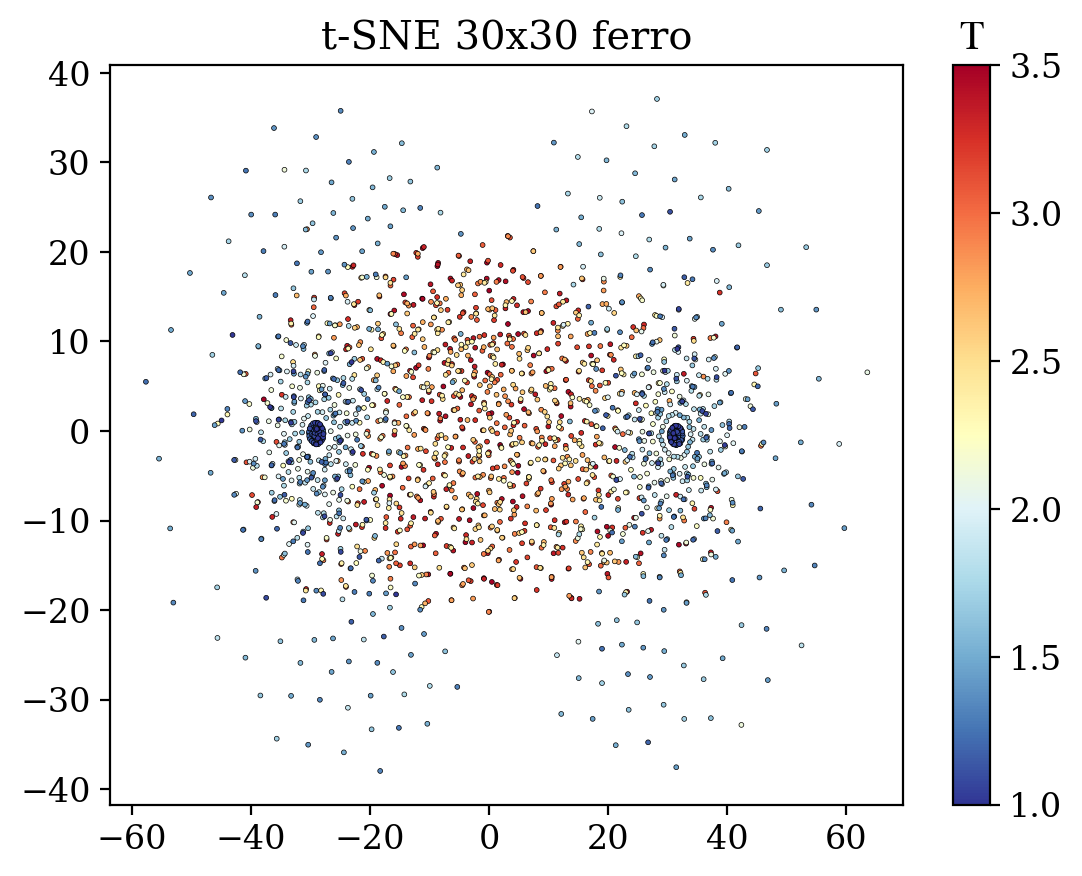

In [11]:
fig_tSNE_1


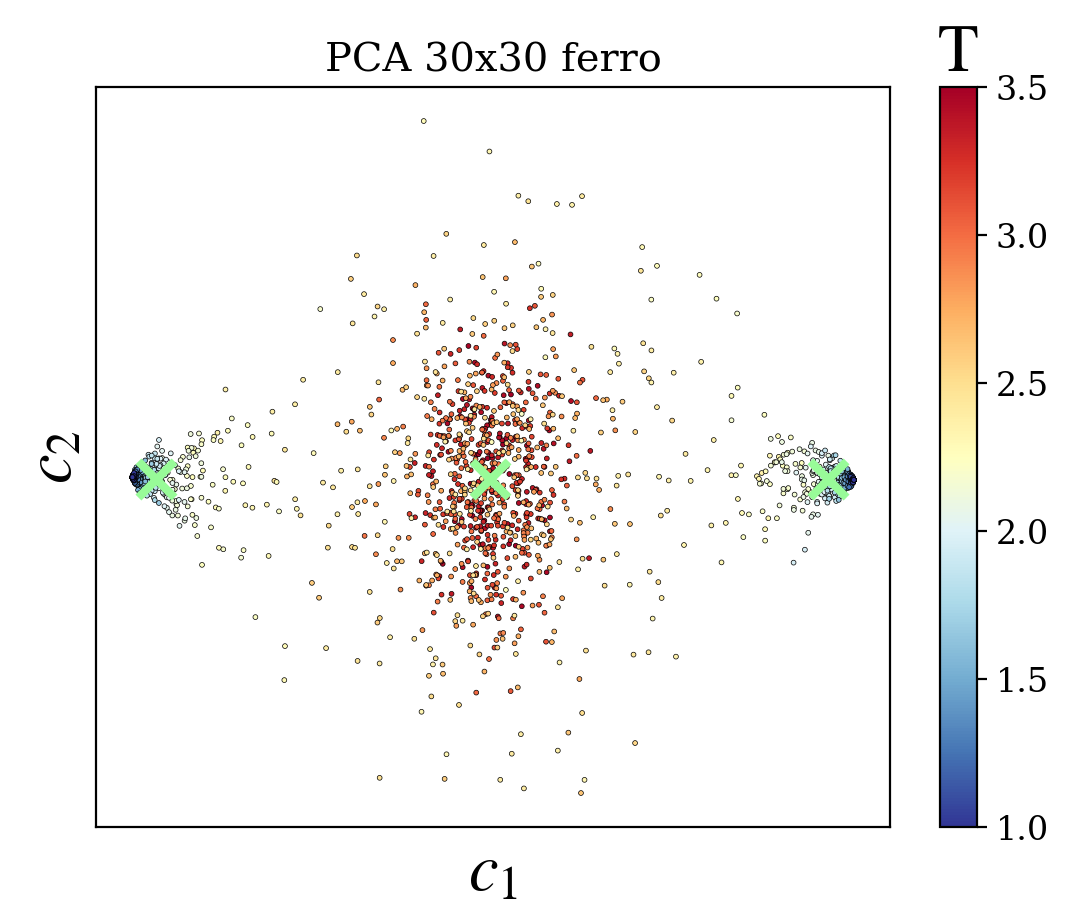

In [12]:
fig_PCA_1

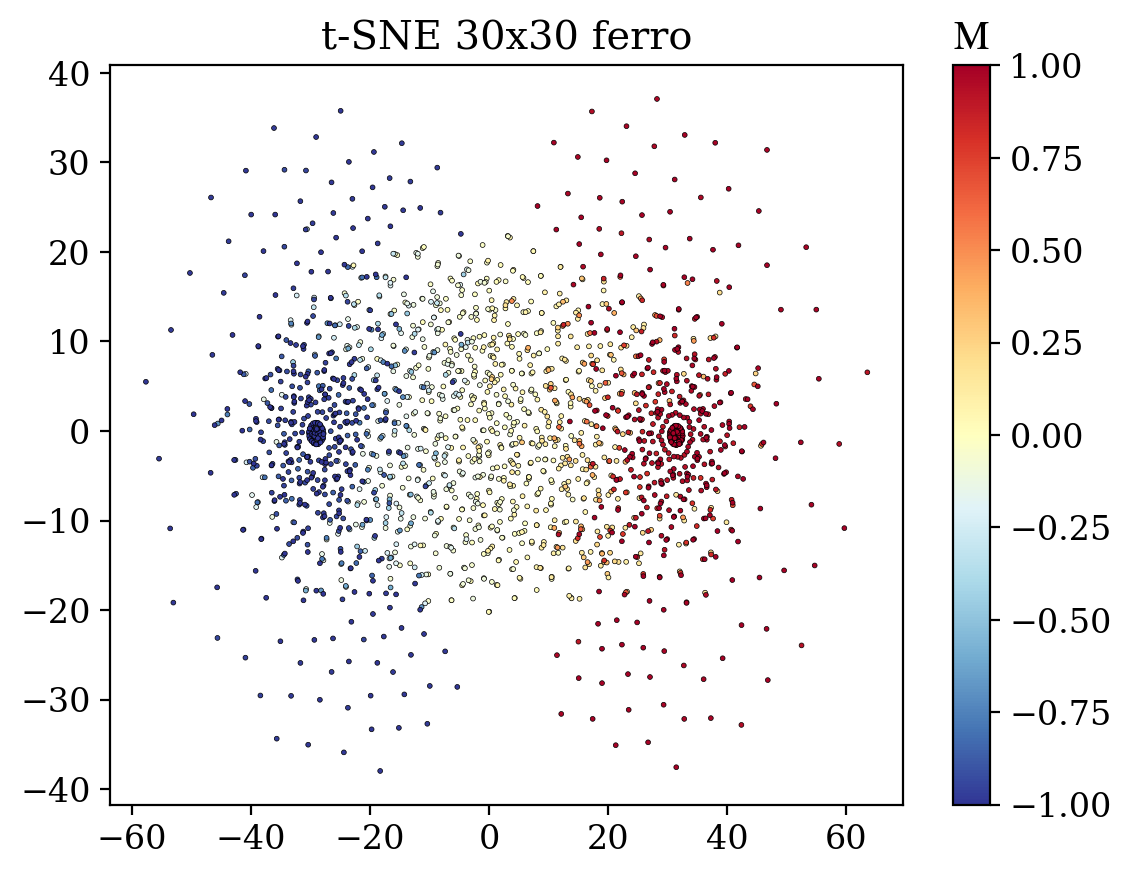

In [13]:
fig_tSNE_2


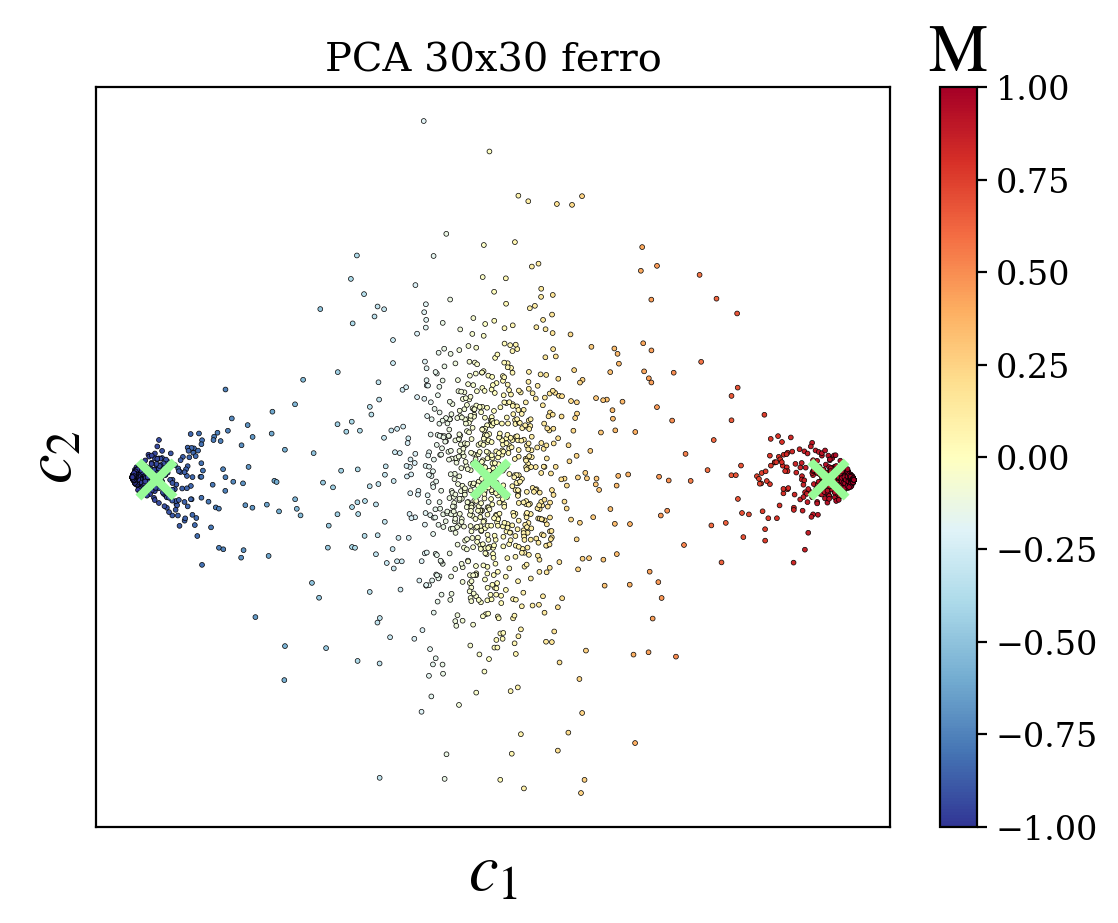

In [14]:
fig_PCA_2

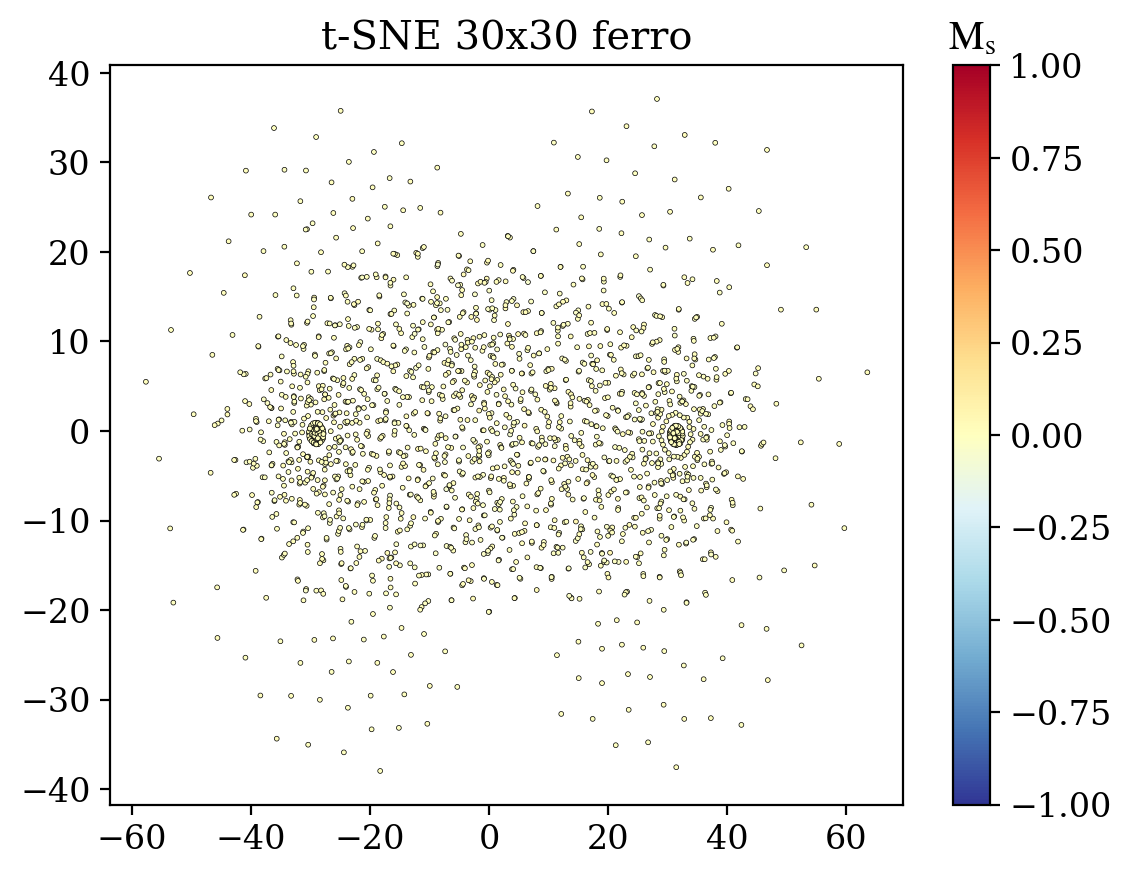

In [15]:
fig_tSNE_3

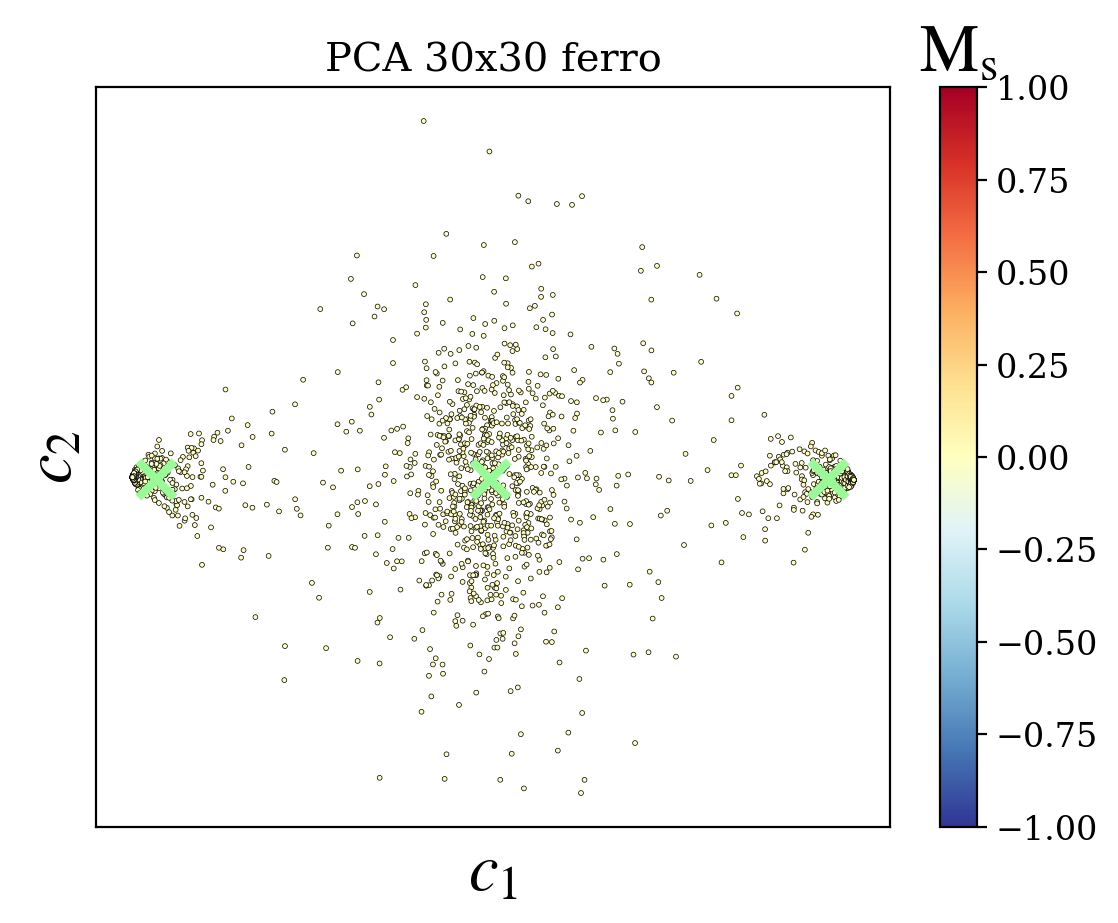

In [16]:
fig_PCA_3

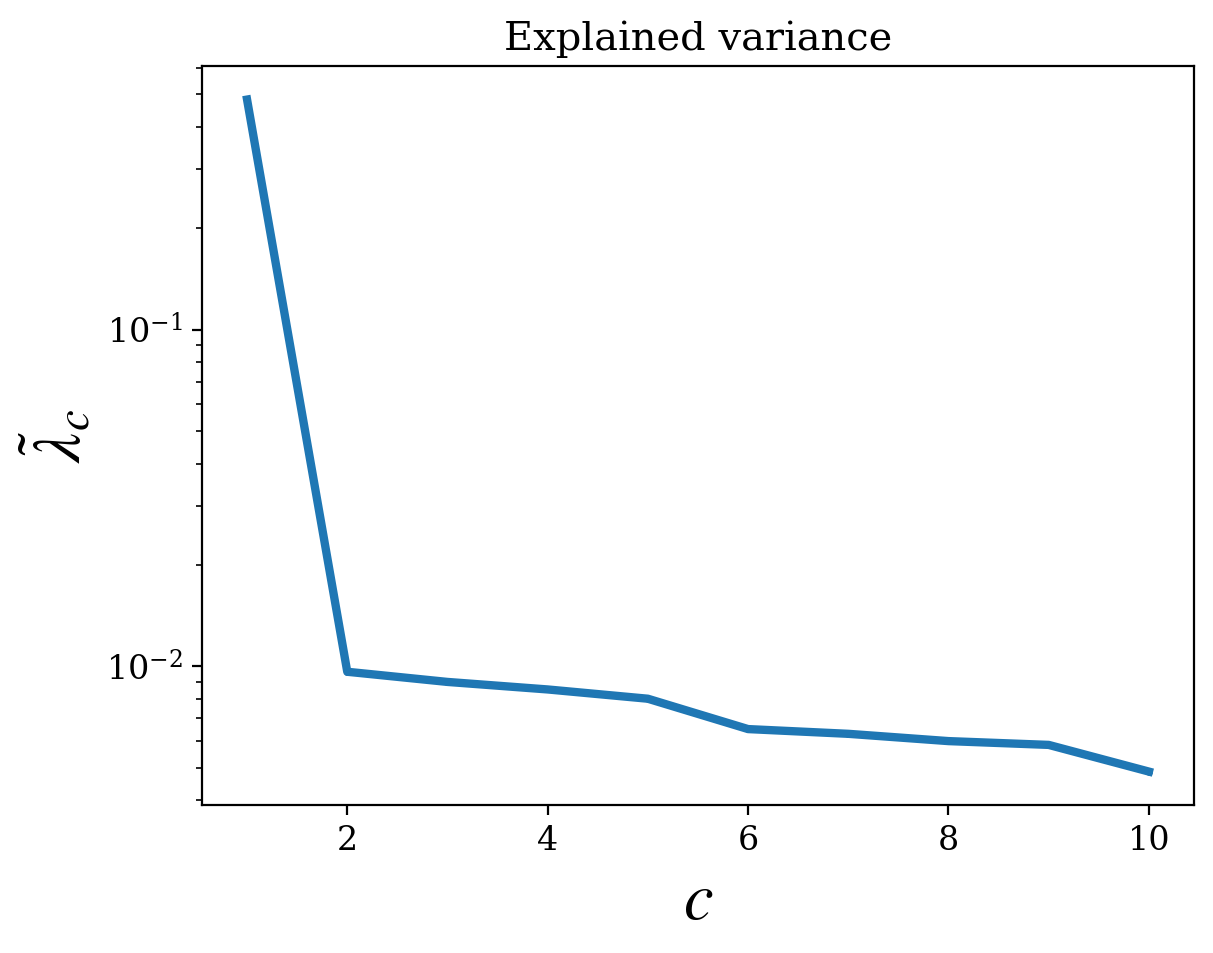

In [17]:
fig_varPCA

In [18]:
print(staggered_magnetization)
print(max(staggered_magnetization))
print(min(staggered_magnetization))

[-0.00444444 -0.02222222  0.02888889 ...  0.          0.
  0.        ]
0.051111111111111114
-0.057777777777777775
